In [1]:
# Data collection command:
# `python comet_download.py --project=stationary-binary-regression --n_threads=8`
# `python comet_download.py --project=ns-binary-regression --n_threads=8`

In [2]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.feature_search.analysis.analysis_utils import *
from phd.feature_search.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

In [3]:
save_path = 'figures/'

# Define both stationary and non-stationary paths
s_config_data_path = 'data/stationary-binary-regression_params.csv'
s_run_data_path = 'data/stationary-binary-regression_metrics.csv'
ns_config_data_path = 'data/ns-binary-regression_params.csv'
ns_run_data_path = 'data/ns-binary-regression_metrics.csv'

# Load both datasets
s_config_dfs, s_run_dfs = load_experiment_data(s_config_data_path, s_run_data_path)
ns_config_dfs, ns_run_dfs = load_experiment_data(ns_config_data_path, ns_run_data_path)

del s_config_dfs['autostep'], s_config_dfs['sgd_layerwise_step_size']
del s_run_dfs['autostep'], s_run_dfs['sgd_layerwise_step_size']

# Remove jax_jit_cache_dir column if present in config dfs
for cfg in itertools.chain(s_config_dfs.values(), ns_config_dfs.values()):
    if "jax_jit_cache_dir" in cfg.columns:
        cfg.drop(columns=["jax_jit_cache_dir"], inplace=True)

# Combine with prefixes
config_dfs = {}
for k, v in s_config_dfs.items():
    config_dfs["s_" + str(k).replace('_v2', '')] = v
for k, v in ns_config_dfs.items():
    config_dfs["ns_" + str(k)] = v

run_dfs = {}
for k, v in s_run_dfs.items():
    run_dfs["s_" + str(k).replace('_v2', '')] = v
for k, v in ns_run_dfs.items():
    run_dfs["ns_" + str(k)] = v

{k: len(v) for k, v in config_dfs.items()}

{'s_adam': 40,
 's_autostep': 80,
 's_sgd_layerwise_step_size': 80,
 'ns_autostep': 125,
 'ns_sgd_layerwise_step_size': 150}

In [4]:
print("_____Best Hyperparameter Configurations_____")
best_config_dfs, best_run_dfs, best_hyperparam_vals = get_best_ablation_values(config_dfs, run_dfs)

_____Best Hyperparameter Configurations_____

=== s_adam ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|learning_rate=2**-4


=== s_autostep ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|learning_rate=2**8
  Best optimizer|meta_learning_rate=2**-4


=== s_sgd_layerwise_step_size ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|learning_rate=2**-18
  Best representation_optimizer|learning_rate=2**2


=== ns_autostep ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|learning_rate=2**8
  Best optimizer|meta_learning_rate=2**-4


=== ns_sgd_layerwise_step_size ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|learning_rate=2**-18
  Best representation_optimizer|learning_rate=2**2



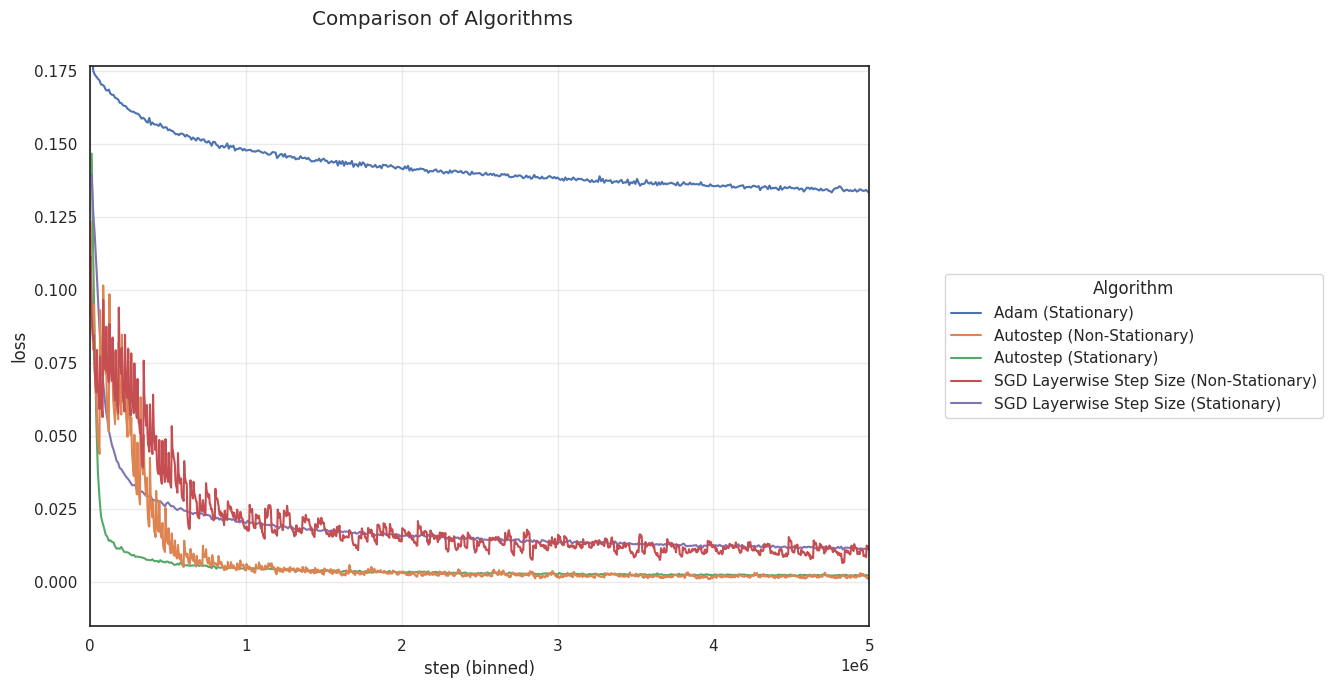

In [18]:
combined_run_df = pd.concat([
    df.assign(sweep_key=key) for key, df in best_run_dfs.items()
], ignore_index=True)
combined_config_df = pd.concat([
    df.assign(sweep_key=key) for key, df in best_config_dfs.items()
], ignore_index=True)

algo_map = {
    'ns_sgd_layerwise_step_size': 'SGD Layerwise Step Size (Non-Stationary)',
    'ns_autostep': 'Autostep (Non-Stationary)',
    's_autostep': 'Autostep (Stationary)',
    's_sgd_layerwise_step_size': 'SGD Layerwise Step Size (Stationary)',
    's_adam': 'Adam (Stationary)',
}

# Only keep rows whose sweep_key is in algo_map
combined_config_df = combined_config_df[combined_config_df['sweep_key'].isin(algo_map.keys())].copy()
valid_run_ids = combined_config_df['run_id'].unique()
combined_run_df = combined_run_df[combined_run_df['run_id'].isin(valid_run_ids)].copy()
combined_config_df['algo'] = combined_config_df['sweep_key'].map(algo_map)

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = -1,
    figsize = (9, 7),
    hue_col = 'algo',
    legend_title = 'Algorithm',
)
plt.subplots_adjust(top=0.9)
plt.suptitle('Comparison of Algorithms')
plt.show()


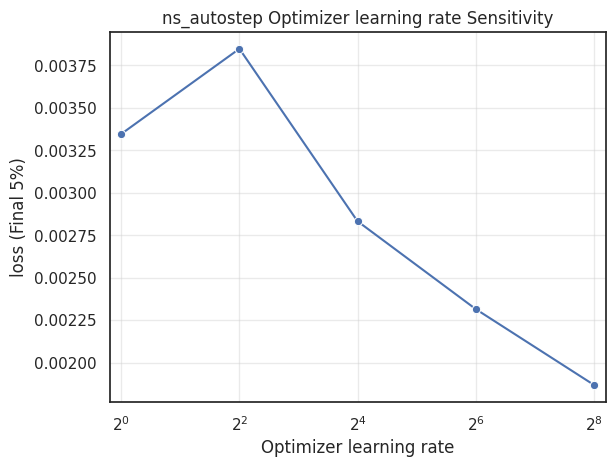

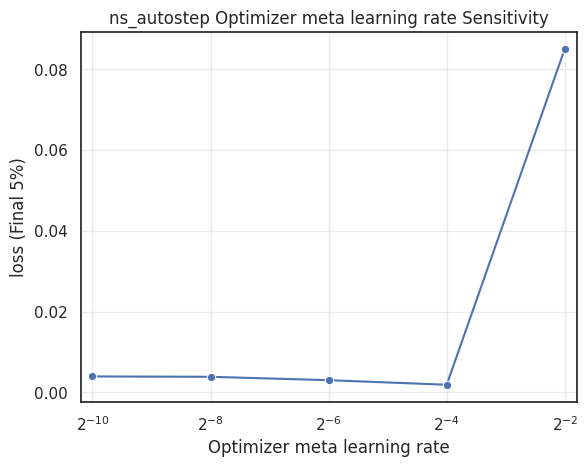

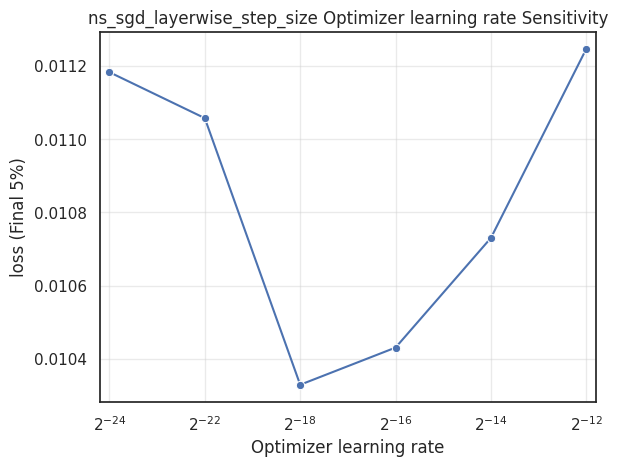

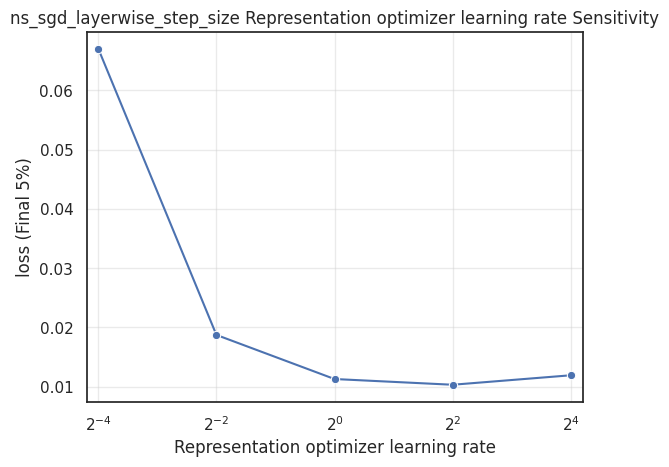

In [19]:
for target_df in ['ns_autostep', 'ns_sgd_layerwise_step_size']:
    default_hyperparams = best_hyperparam_vals[target_df]

    plot_config_df = config_dfs[target_df]
    valid_run_ids = plot_config_df['run_id'].unique()
    plot_run_df = run_dfs[target_df][run_dfs[target_df]['run_id'].isin(valid_run_ids)].copy()

    for param_name, param_value in default_hyperparams.items():
        selected_run_df, selected_config_df = select_experiment_runs(
            run_df = plot_run_df,
            config_df = plot_config_df,
            chosen_values = {
                k: v for k, v in default_hyperparams.items()
                if k != param_name
            },
        )
        
        param_label = param_name.replace('|', ' ').replace('_', ' ').capitalize()
        
        plot_param_sensitivity(
                run_df = selected_run_df,
                config_df = selected_config_df,
                x_col = param_name,
                title = f'{target_df} {param_label} Sensitivity',
                x_label = param_label,
                y_label = 'loss',
                metric_col = 'loss',
                metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
                step_col = 'step',
                legend_title = None,
                show_ci = False,
                baseline_col = None,
                pow_2_x_axis = 'learning_rate' in param_name,
                pow_2_legend = True,
            )
        plt.show()